In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings("ignore")

print("All libraries imported successfully.")

All libraries imported successfully.


In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 1000

data = {
    "Latitude": np.random.uniform(8.0, 37.0, n),
    "Longitude": np.random.uniform(68.0, 97.0, n),
    "Property_Value": np.random.randint(1000000, 10000000, n),
    "Income": np.random.randint(20000, 150000, n),
    "Population_Density": np.random.randint(100, 10000, n),
    "Amenities_Score": np.random.randint(1, 11, n)
}

df = pd.DataFrame(data)

df.to_csv("real_estate_geographic_dataset.csv", index=False)

print("Dataset created successfully!")
df.head()

Dataset created successfully!


,Latitude,Longitude,Property_Value,Income,Population_Density,Amenities_Score
0,18.861663,73.368855,4801250,85942,7082,2
1,35.570715,83.715127,1019675,33689,7527,4
2,29.227824,93.315429,9462605,52934,6436,9
3,25.361096,89.234522,1486799,53276,1778,2
4,12.524541,91.390273,7810805,136349,715,3


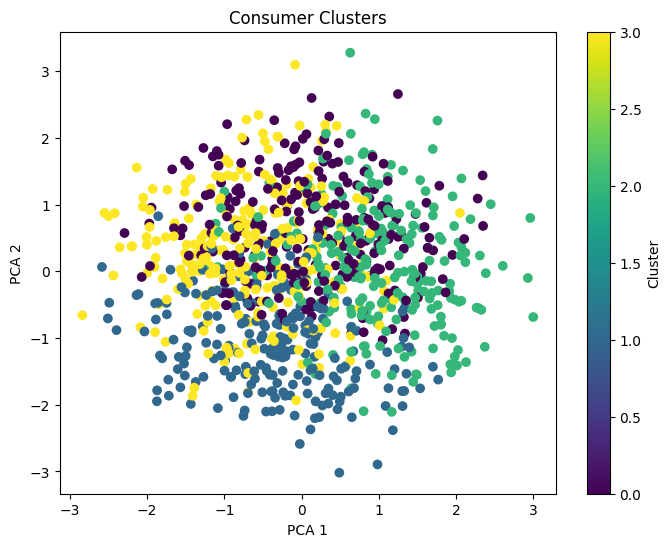

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X = df

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap="viridis")
plt.title("Consumer Clusters")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(label="Cluster")
plt.show()

In [ ]:
print(df.shape)

print(df.info())

print(df.describe())

(1000, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Latitude            1000 non-null   float64
 1   Longitude           1000 non-null   float64
 2   Property_Value      1000 non-null   int64  
 3   Income              1000 non-null   int64  
 4   Population_Density  1000 non-null   int64  
 5   Amenities_Score     1000 non-null   int64  
 6   Cluster             1000 non-null   int32  
dtypes: float64(2), int32(1), int64(4)
memory usage: 50.9 KB
None
          Latitude    Longitude  Property_Value         Income  \
count  1000.000000  1000.000000    1.000000e+03    1000.000000   
mean     22.217440    82.703502    5.520343e+06   84735.324000   
std       8.471983     8.473507    2.568851e+06   37815.086788   
min       8.134329    68.093330    1.017297e+06   20112.000000   
25%      14.843225    74.991154    3.337202e+06 

In [ ]:
print(df.isnull().sum())

Latitude              0
Longitude             0
Property_Value        0
Income                0
Population_Density    0
Amenities_Score       0
Cluster               0
dtype: int64


In [ ]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

scaled_data

array([[-0.39630103, -1.10217857, -0.28006805, ...,  0.72901268,
        -1.22551226,  0.41327256],
       [ 1.57695733,  0.11944663, -1.75289267, ...,  0.88447423,
        -0.53469362, -1.35663132],
       [ 0.82789256,  1.25299211,  1.53540788, ...,  0.50333141,
         1.19235296, -1.35663132],
       ...,
       [-1.21044009, -1.49997824, -0.79245208, ..., -0.17790461,
         0.84694364, -0.47167938],
       [ 1.57532388, -1.54073684, -0.45805761, ..., -1.38910733,
         0.15612501, -0.47167938],
       [-0.15154831, -0.76985117, -0.19359395, ..., -0.89302776,
        -0.18928431, -0.47167938]])

In [ ]:
wcss=[]

for i in range(1,11):

    kmeans=KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_data)

    wcss.append(kmeans.inertia_)


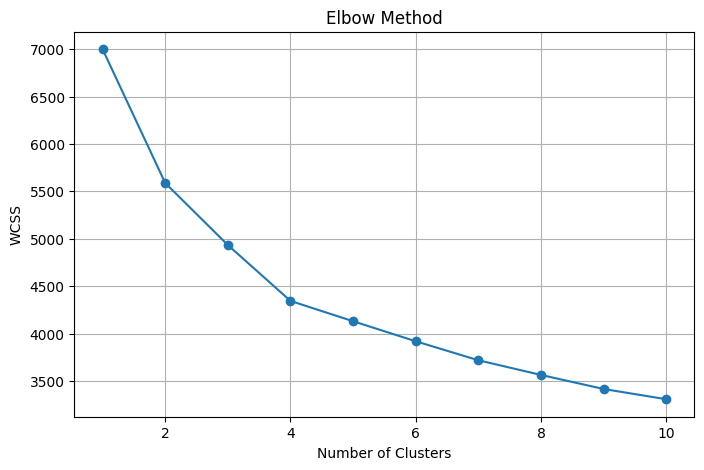

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11),wcss,marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.grid(True)

plt.show()

In [ ]:
kmeans=KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters=kmeans.fit_predict(scaled_data)

df["Cluster"]=clusters

df.head()

,Latitude,Longitude,Property_Value,Income,Population_Density,Amenities_Score,Cluster
0,18.861663,73.368855,4801250,85942,7082,2,0
1,35.570715,83.715127,1019675,33689,7527,4,3
2,29.227824,93.315429,9462605,52934,6436,9,3
3,25.361096,89.234522,1486799,53276,1778,2,3
4,12.524541,91.390273,7810805,136349,715,3,2


In [ ]:
print(df["Cluster"].value_counts())

Cluster
2    265
0    252
3    249
1    234
Name: count, dtype: int64


In [ ]:
pca=PCA(n_components=2)

principal_components=pca.fit_transform(scaled_data)

pca_df=pd.DataFrame(
    principal_components,
    columns=["PC1","PC2"]
)

pca_df["Cluster"]=clusters

pca_df.head()

,PC1,PC2,Cluster
0,0.110917,1.357530,0
1,-2.000082,0.527965,3
2,-1.369010,-1.576807,3
3,-1.807029,0.123577,3
4,1.556866,-0.178730,2


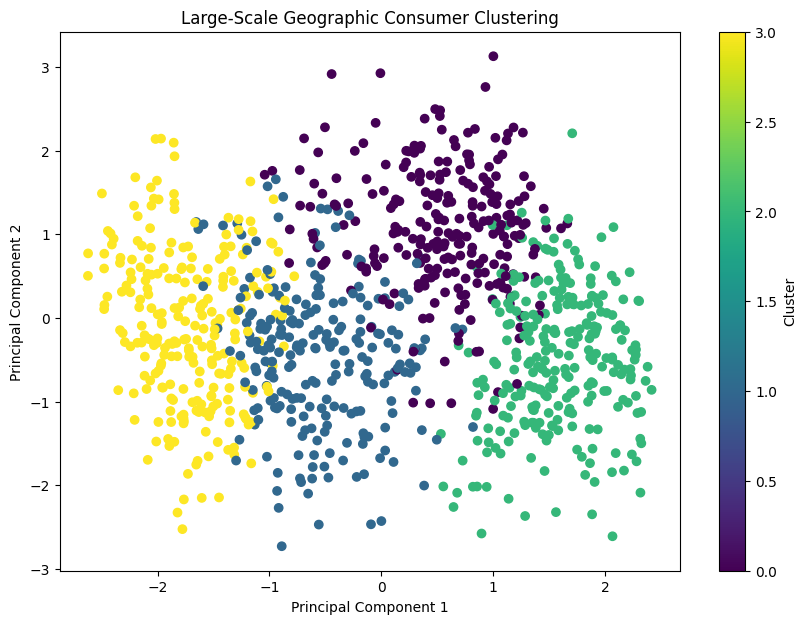

In [ ]:
plt.figure(figsize=(10,7))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["Cluster"],
    cmap="viridis"
)

plt.title("Large-Scale Geographic Consumer Clustering")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.colorbar(label="Cluster")

plt.show()

In [ ]:
summary=df.groupby("Cluster").mean()

print(summary)

          Latitude  Longitude  Property_Value         Income  \
Cluster                                                        
0        20.935576  78.520289    4.635977e+06  109080.714286   
1        20.565829  75.306058    5.939395e+06   57324.388889   
2        23.990229  86.086428    6.081177e+06  115088.607547   
3        23.180161  90.288626    5.424686e+06   53552.594378   

         Population_Density  Amenities_Score  
Cluster                                       
0               6374.519841         3.134921  
1               4489.782051         7.252137  
2               4022.486792         7.539623  
3               5109.618474         4.269076  
